In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

df=pd.read_csv('https://raw.githubusercontent.com/Ann805/Sleep/main/Sleep_health_and_lifestyle_dataset.csv')
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
print('Data Shape:')
df.shape

Data Shape:


(374, 13)

In [ ]:

print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isna().sum().sort_values(ascending=False))

Data Types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing Values:
Sleep Disorder             219
Gender                       0
Age                          0
Occupation                   0
Person ID                    0
Sleep Duration               0
Quality of Sleep             0
Stress Level                 0
Physical Activity Level      0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
dtype: int64


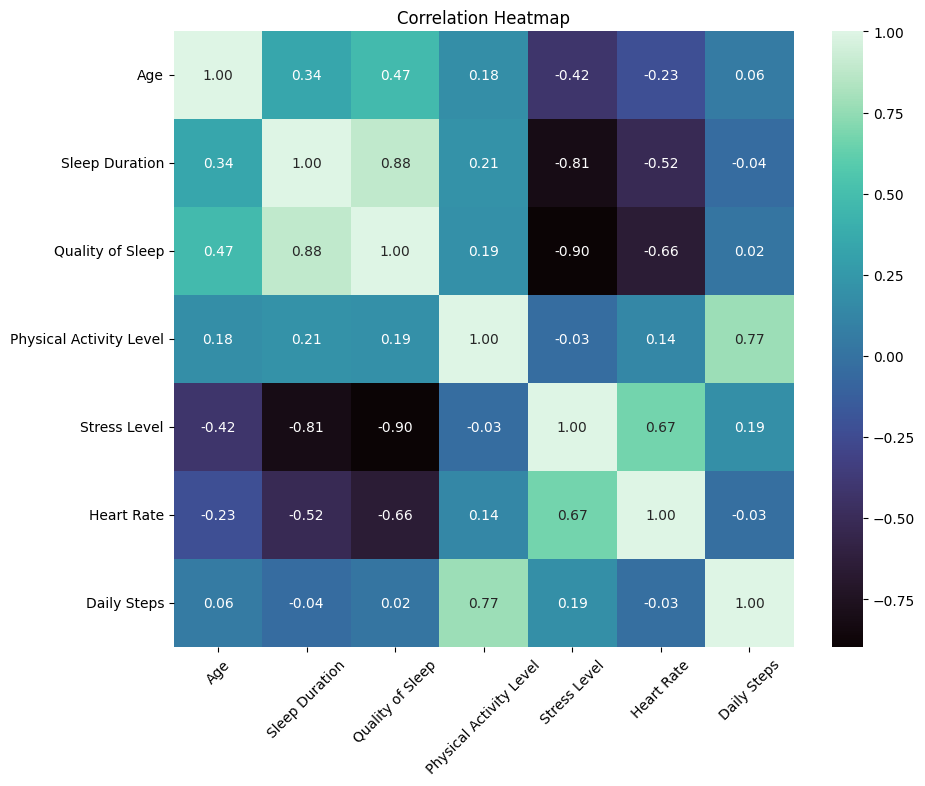

In [ ]:
#Charts
#Heatmap
numerical = df.select_dtypes(include="number")
numerical = numerical.drop(columns=["Person ID"])

correlation = numerical.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="mako",
    fmt=".2f"
)
plt.xticks(rotation=45)

plt.title("Correlation Heatmap")
plt.show()


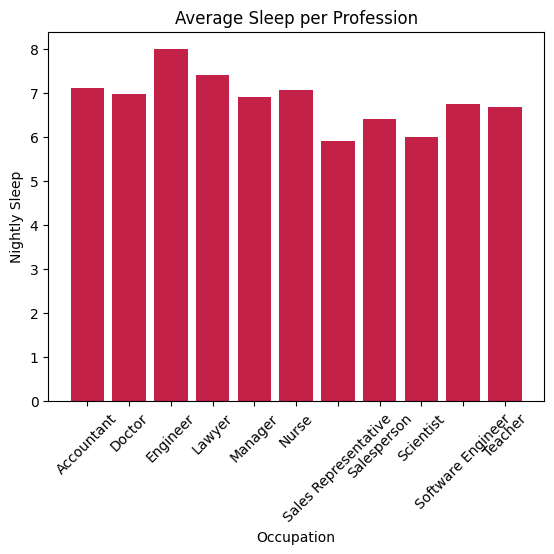

In [ ]:
occu_avg = df.groupby('Occupation')['Sleep Duration'].mean()

plt.bar(occu_avg.index, occu_avg.values,
        color='#C32148')
plt.xticks(rotation=45)
plt.xlabel('Occupation')
plt.ylabel('Nightly Sleep')
plt.title('Average Sleep per Profession')
plt.show()


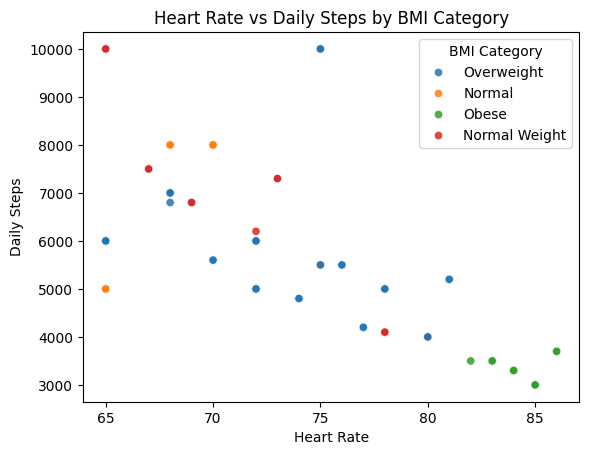

In [ ]:
sns.scatterplot(
    data=df,
    x='Heart Rate',
    y='Daily Steps',
    hue='BMI Category',
    alpha=0.85
)

plt.xlabel('Heart Rate')
plt.ylabel('Daily Steps')
plt.title('Heart Rate vs Daily Steps by BMI Category')
plt.show()

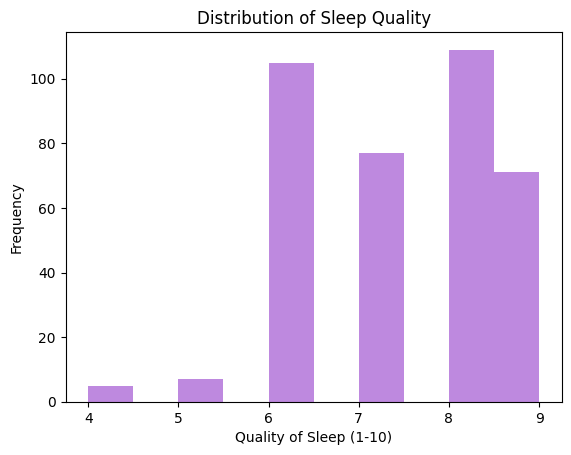

In [ ]:
plt.hist(df['Quality of Sleep'],color='#BE89DF', bins=10)

plt.xlabel('Quality of Sleep (1-10)')
plt.ylabel('Frequency')
plt.title('Distribution of Sleep Quality')

plt.show()

In [ ]:

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df["Sleep Disorder"].unique()



array(['None', 'Sleep Apnea', 'Insomnia'], dtype=object)

In [ ]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Occupation', 'BMI Category'],
    drop_first=True,
    dtype=int)



In [ ]:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split(
    '/', expand=True
).astype(int)

df.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Systolic BP,Diastolic BP
0,1,27,6.1,6,42,6,126/83,77,4200,None,...,0,0,0,1,0,0,0,1,126,83
1,2,28,6.2,6,60,8,125/80,75,10000,None,...,0,0,0,0,0,0,0,0,125,80
2,3,28,6.2,6,60,8,125/80,75,10000,None,...,0,0,0,0,0,0,0,0,125,80
3,4,28,5.9,4,30,8,140/90,85,3000,Sleep Apnea,...,1,0,0,0,0,0,1,0,140,90
4,5,28,5.9,4,30,8,140/90,85,3000,Sleep Apnea,...,1,0,0,0,0,0,1,0,140,90


In [ ]:
X = df.drop(columns=['Person ID','Sleep Disorder','Blood Pressure'])
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
print(X.dtypes)

Age                                  int64
Sleep Duration                     float64
Quality of Sleep                     int64
Physical Activity Level              int64
Stress Level                         int64
Heart Rate                           int64
Daily Steps                          int64
Gender_Male                          int64
Occupation_Doctor                    int64
Occupation_Engineer                  int64
Occupation_Lawyer                    int64
Occupation_Manager                   int64
Occupation_Nurse                     int64
Occupation_Sales Representative      int64
Occupation_Salesperson               int64
Occupation_Scientist                 int64
Occupation_Software Engineer         int64
Occupation_Teacher                   int64
BMI Category_Normal Weight           int64
BMI Category_Obese                   int64
BMI Category_Overweight              int64
Systolic BP                          int64
Diastolic BP                         int64
dtype: obje

In [ ]:
#decision Trees

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

tree_preds = tree.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)

print(f"Decision Tree accuracy: {tree_acc:.4f}")

Decision Tree accuracy: 0.9333


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame(
    {'Decision Tree': [
        tree_acc,
        precision_score(y_test, tree_preds, average='weighted'),
        recall_score(y_test, tree_preds, average='weighted'),
        f1_score(y_test, tree_preds, average='weighted'),
    ]},
    index=['Accuracy', 'Precision', 'Recall', 'F1-score']
)
results.round(4)


,Decision Tree
Accuracy,0.9333
Precision,0.9338
Recall,0.9333
F1-score,0.9332


In [ ]:
print("Train Accuracy:", tree.score(X_train, y_train))
print("Test Accuracy:", tree.score(X_test, y_test))

Train Accuracy: 0.903010033444816
Test Accuracy: 0.9333333333333333


In [ ]:
print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

    Insomnia       0.86      0.80      0.83        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.82      0.88      0.85        16

    accuracy                           0.93        75
   macro avg       0.89      0.89      0.89        75
weighted avg       0.93      0.93      0.93        75



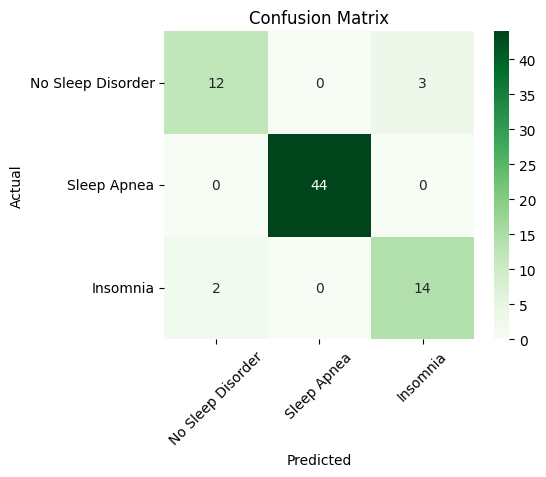

In [ ]:

cm = confusion_matrix(y_test,tree_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Sleep Disorder', 'Sleep Apnea', 'Insomnia'], yticklabels=['No Sleep Disorder', 'Sleep Apnea', 'Insomnia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

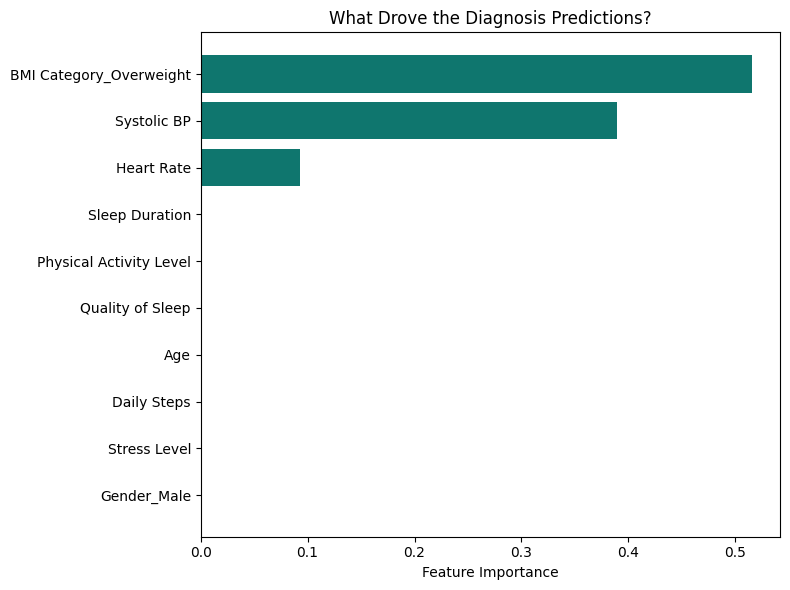

,0
BMI Category_Overweight,0.516123
Systolic BP,0.389385
Heart Rate,0.092995
Sleep Duration,0.001496
Physical Activity Level,0.000000
Quality of Sleep,0.000000
Age,0.000000
Daily Steps,0.000000
Stress Level,0.000000
Gender_Male,0.000000


In [ ]:
importances = pd.Series(
    tree.feature_importances_, index=X.columns
).sort_values(ascending=False)

top10 = importances.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10.index[::-1], top10.values[::-1], color='#0F766E')
plt.xlabel('Feature Importance')
plt.title('What Drove the Diagnosis Predictions?')
plt.tight_layout()
plt.show()

top10



In [ ]:
depths = range(1, 16)
train_accs, test_accs = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker='o', color='#F97316', label='Training accuracy')
plt.plot(depths, test_accs, marker='o', color='#0F766E', label='Test accuracy')
plt.xlabel('Tree Depth (model complexity)')
plt.ylabel('Accuracy')
plt.title('Deeper Trees Memorize Training Data')
plt.legend()
plt.show()

best_depth = depths[int(np.argmax(test_accs))]
print(f"Best test accuracy at max_depth = {best_depth}")